In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pystout import pystout
from scipy.stats import ttest_ind
from itertools import combinations, product

color_scheme = ["#3c5488", "#e64b35", "#4dbbd5", "#00a087", "#f39b7f"]

In [3]:
def set_plot_theme():
    # base seaborn theme & palette
    sns.set_theme(
        style="white",           # consistent with file_context_0
        palette=["#3c5488", "#e64b35", "#4dbbd5", "#00a087", "#f39b7f"],          # or your own list of colors
        font="serif",            # consistent with file_context_0
        font_scale=1.1
    )

    # tweak matplotlib rcParams you care about
    plt.rcParams.update({
        "text.usetex":       True,  # consistent with file_context_0
        "axes.titlesize":    16,
        "axes.labelsize":    14,
        "legend.frameon":    False,
        "figure.figsize":    (8, 5),
        "lines.linewidth":   2,
        "lines.markersize":  6,
        # …any other defaults…
    })

def finalize_plot(ax=None):
    if ax is None:
        ax = plt.gca()
    sns.despine(ax=ax)
    ax.figure.tight_layout()

In [4]:
df = pd.read_csv("/Users/nicolasroever/Dropbox/Promotion/Bargaining/bargaining_experiment_analysis/bld/data/merged_data_full_excluded.csv")

In [5]:
df01 = df[(df['split_gains_from_trade'] >= 0) & (df['split_gains_from_trade'] <= 1)]

df01_time = df01[np.isclose(df01['time_inconsistency_dummy'], 0)]

In [6]:
df01 = df[(df['split_gains_from_trade'] >= 0) & (df['split_gains_from_trade'] <= 1)]
df01_time = df01[np.isclose(df01['time_inconsistency_dummy'], 0)]


#Model One: First Offer
data_time_model = df01_time.dropna(subset=['first_offer', 'information_asymmetry'])
model_t12 = smf.ols(formula='split_gains_from_trade ~ first_offer:C(information_asymmetry)', 
                    data=data_time_model).fit(
    cov_type='cluster',
    cov_kwds={'groups': data_time_model['participant_code']}
                    )

print(model_t12.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.002
Model:                                OLS   Adj. R-squared:                  0.001
Method:                     Least Squares   F-statistic:                     1.215
Date:                    Tue, 15 Jul 2025   Prob (F-statistic):              0.299
Time:                            14:53:24   Log-Likelihood:                 225.15
No. Observations:                    2225   AIC:                            -444.3
Df Residuals:                        2222   BIC:                            -427.2
Df Model:                               2                                         
Covariance Type:                  cluster                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [7]:
model_t12 = smf.ols(formula='split_gains_from_trade ~ first_offer:C(information_asymmetry)', 
                      data=df01_time).fit()

print(model_t12.summary())


                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.002
Model:                                OLS   Adj. R-squared:                  0.001
Method:                     Least Squares   F-statistic:                     2.036
Date:                    Tue, 15 Jul 2025   Prob (F-statistic):              0.131
Time:                            14:53:24   Log-Likelihood:                 225.15
No. Observations:                    2225   AIC:                            -444.3
Df Residuals:                        2222   BIC:                            -427.2
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------

In [8]:
model_t12 = smf.ols(formula='split_gains_from_trade ~ + ultimatum_indicator + risk_elicitation_choice + time_preference_switching_points', 
                      data=df01).fit()

print(model_t12.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.004
Model:                                OLS   Adj. R-squared:                  0.003
Method:                     Least Squares   F-statistic:                     3.546
Date:                    Tue, 15 Jul 2025   Prob (F-statistic):             0.0140
Time:                            14:53:24   Log-Likelihood:                 234.42
No. Observations:                    2379   AIC:                            -460.8
Df Residuals:                        2375   BIC:                            -437.7
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [9]:
df_t12 = df[(df['treatment'].isin(['T1', 'T2'])) & (df['bargaining_outcome'] == 'acceptance')].copy()
df_model_t12 = df_t12.dropna(subset=['split_gains_from_trade'])

model_t12 = smf.ols(formula='split_gains_from_trade ~ C(participant_role) + C(participant_role):valuation', 
                      data=df_model_t12).fit(
    cov_type='cluster',
     cov_kwds={'groups': df_model_t12['participant_code']}
                      )
print(model_t12.summary())

                              OLS Regression Results                              
Dep. Variable:     split_gains_from_trade   R-squared:                       0.015
Model:                                OLS   Adj. R-squared:                  0.011
Method:                     Least Squares   F-statistic:                     2.102
Date:                    Tue, 15 Jul 2025   Prob (F-statistic):              0.103
Time:                            14:53:24   Log-Likelihood:                -711.77
No. Observations:                     855   AIC:                             1432.
Df Residuals:                         851   BIC:                             1451.
Df Model:                               3                                         
Covariance Type:                  cluster                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

In [10]:
avg_split_gains_seller_t1_t2 = df.loc[
    (df['participant_role'] == 'Seller') &
    (df['treatment'].isin(['T1', 'T2'])) &
    (df['gains_from_trade'] >= 0) &
    (df['gains_from_trade'] <= 30)
]['split_gains_from_trade'].mean()
print(f"Average split_gains_from_trade for Sellers (T1 or T2): {avg_split_gains_seller_t1_t2:.4f}")

avg_split_gains_seller_t3_t4 = df.loc[
    (df['participant_role'] == 'Seller') &
    (df['treatment'].isin(['T3', 'T4']))
]['split_gains_from_trade'].mean()
print(f"Average split_gains_from_trade for Sellers (T3 or T4): {avg_split_gains_seller_t3_t4:.4f}")

Average split_gains_from_trade for Sellers (T1 or T2): 0.5045
Average split_gains_from_trade for Sellers (T3 or T4): 0.5292


/var/folders/f_/lhmm20kd6r979skh60tngks80000gn/T/ipykernel_84839/187451770.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([g1_w, g2_w], labels=['T1 and T2', 'T3 and T4'],


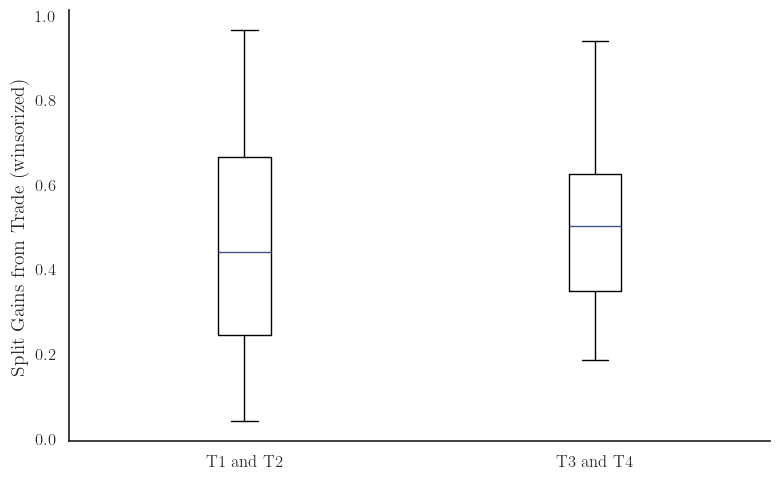

In [13]:
# 1. Subset seller data
seller = df[df['participant_role'] == 'Seller']

# 2. Pull out the two groups
g1 = seller[seller['treatment'].isin(['T1','T2'])]['split_gains_from_trade'].dropna()
g2 = seller[seller['treatment'].isin(['T3','T4'])]['split_gains_from_trade'].dropna()

# 3. Compute 1% and 99% bounds for each
low1, high1 = g1.quantile([0.05, 0.95])
low2, high2 = g2.quantile([0.05, 0.95])

# 4. Winsorize (clip) each series
g1_w = g1.clip(lower=low1, upper=high1)
g2_w = g2.clip(lower=low2, upper=high2)

set_plot_theme()
# 5. Plot
fig, ax = plt.subplots()
ax.boxplot([g1_w, g2_w], labels=['T1 and T2', 'T3 and T4'], 
           medianprops={'color': sns.color_palette()[0] },)
ax.set_ylabel('Split Gains from Trade (winsorized)')
finalize_plot(ax)
plt.show()

In [12]:
print(df['split_gains_from_trade'].describe())


count    2485.000000
mean        0.500750
std         0.458904
min        -7.000000
25%         0.333333
50%         0.500000
75%         0.666667
max         8.000000
Name: split_gains_from_trade, dtype: float64


In [23]:
df_model = df[(df["participant_role"] == "Seller") & (df["treatment"].isin([ 'T1', 'T3']))].copy()
df_model = df_model.dropna(subset=['split_gains_from_trade'])


information_rent = smf.ols(formula='payoff ~ seller_info_public + gains_from_trade',  
                      data=df_model).fit()
print(information_rent.summary())

                            OLS Regression Results                            
Dep. Variable:                 payoff   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     143.4
Date:                Tue, 15 Jul 2025   Prob (F-statistic):           1.28e-51
Time:                        11:23:39   Log-Likelihood:                -1936.1
No. Observations:                 602   AIC:                             3878.
Df Residuals:                     599   BIC:                             3891.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              1.4275      0

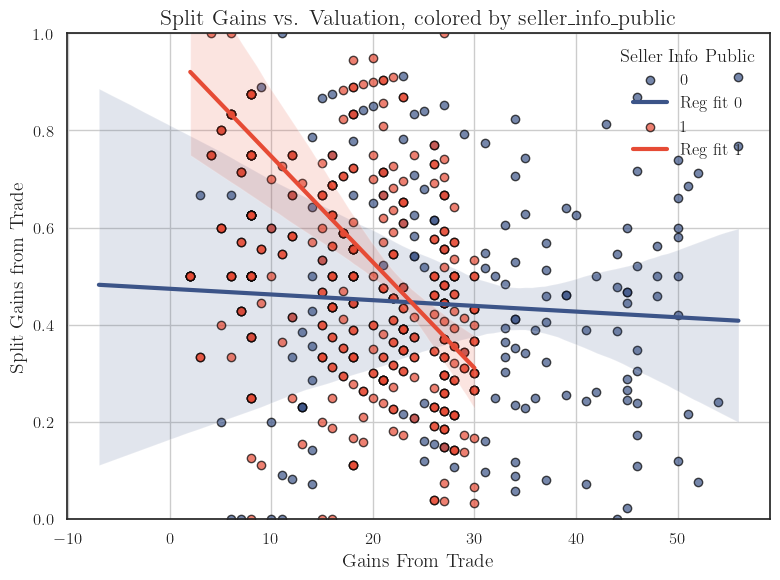

In [24]:
# Group points by the seller_info_public category
df_plot = df_model[df_model['participant_role'] == 'Seller'].copy()
groups = df_model.groupby('seller_info_public')

fig, ax = plt.subplots(figsize=(8,6))
for public_flag, group in groups:
    ax.scatter(
        group['gains_from_trade'],
        group['split_gains_from_trade'],
        label=str(public_flag),
        alpha=0.7,
        edgecolor='k'
    )
    # Add regression fit for each group
    sns.regplot(
        x='gains_from_trade',
        y='split_gains_from_trade',
        data=group,
        scatter=False,
        ax=ax,
        label=f'Reg fit {public_flag}'
    )

ax.set_xlabel('Gains From Trade')
ax.set_ylabel('Split Gains from Trade')
ax.set_title('Split Gains vs. Valuation, colored by seller_info_public')
ax.legend(title='Seller Info Public')
ax.grid(True)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

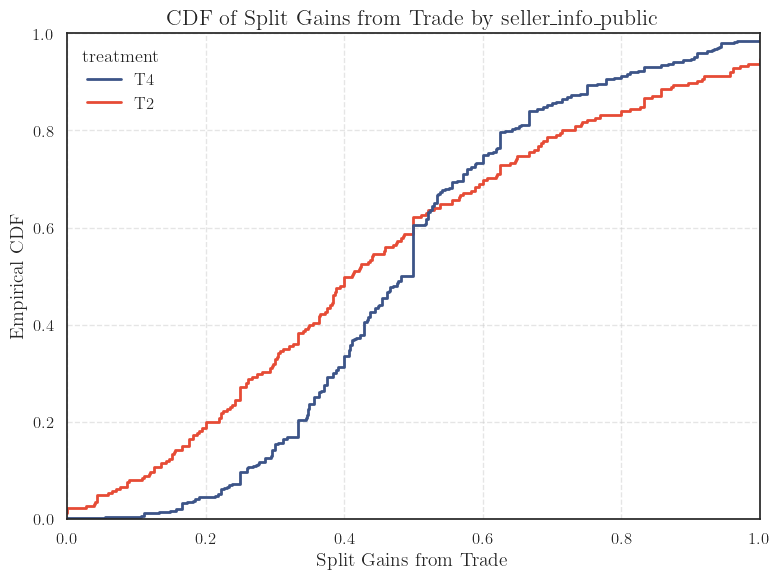

In [25]:
# restrict to Sellers in treatments T2 & T4
df_plot = df[
    (df["participant_role"] == "Seller") & (df['treatment'].isin([ 'T2', 'T4']))
].copy()

plt.figure(figsize=(8, 6))
ax = sns.ecdfplot(
    data=df_plot,
    x='split_gains_from_trade',
    hue='treatment',      # raw True/False values     # optional: fixes order
    stat='proportion'
)

ax.set_xlim(0, 1)

ax.set_xlabel('Split Gains from Trade')
ax.set_ylabel('Empirical CDF')
ax.set_title('CDF of Split Gains from Trade by seller_info_public')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [26]:
# Filter Sellers in treatments T2 & T4
df_plot = df[
    (df["participant_role"] == "Seller") & (df['treatment'].isin(['T1', 'T3']))
].copy()

plt.figure(figsize=(8, 6))

# Scatterplot: payoff vs. gains_from_trade
ax = sns.scatterplot(
    data=df_plot,
    x='gains_from_trade',
    y='payoff',
    hue='treatment',
    alpha=0.7
)

# Regression line for T2
sns.regplot(
    data=df_plot[df_plot['treatment'] == 'T1'],
    x='gains_from_trade',
    y='payoff',
    scatter=False,
    ax=ax,
)

# Regression line for T4
sns.regplot(
    data=df_plot[df_plot['treatment'] == 'T3'],
    x='gains_from_trade',
    y='payoff',
    scatter=False,
    ax=ax,
)

# Add reference line y = 0.5x
x_vals = ax.get_xlim()
x = np.linspace(*x_vals, 100)
y = 0.5 * x
plt.plot(x, y, linestyle='--', color='black', label='y = 0.5x')

# Labels and formatting
ax.set_xlim(0, 30)
ax.set_xlabel('Gains from Trade')
ax.set_ylabel('Payoff')
ax.set_title('Payoff vs. Gains from Trade (Sellers in T2 & T4)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

RuntimeError: latex was not able to process the following string:
b'Payoff vs. Gains from Trade (Sellers in T2 & T4)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp_27v1q09 3aa832b92a0ab54a3d5eca4d1670cd7f5516df8775fcc53c679a5ca7cf072bab.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./3aa832b92a0ab54a3d5eca4d1670cd7f5516df8775fcc53c679a5ca7cf072bab.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/u

Error in callback <function _draw_all_if_interactive at 0x156739a80> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'Payoff vs. Gains from Trade (Sellers in T2 & T4)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpjjo64xc6 3aa832b92a0ab54a3d5eca4d1670cd7f5516df8775fcc53c679a5ca7cf072bab.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./3aa832b92a0ab54a3d5eca4d1670cd7f5516df8775fcc53c679a5ca7cf072bab.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/u

RuntimeError: latex was not able to process the following string:
b'Payoff vs. Gains from Trade (Sellers in T2 & T4)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmp_t64r3ak 3aa832b92a0ab54a3d5eca4d1670cd7f5516df8775fcc53c679a5ca7cf072bab.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./3aa832b92a0ab54a3d5eca4d1670cd7f5516df8775fcc53c679a5ca7cf072bab.tex
LaTeX2e <2022-11-01> patch level 1
L3 programming layer <2023-02-22>
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/article.cls
Document Class: article 2022/07/02 v1.4n Standard LaTeX document class
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2023/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2023/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2023/texmf-dist/tex/latex/base/t1cmr.fd))
(/u

<Figure size 800x600 with 1 Axes>

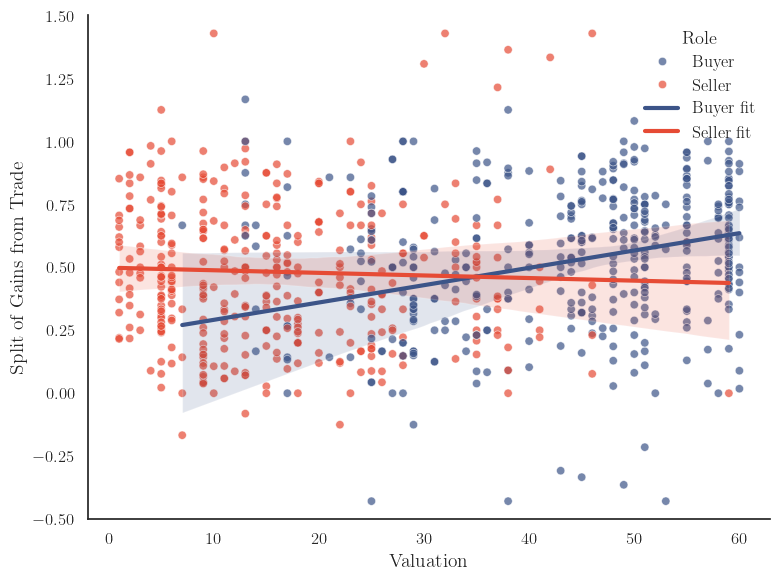

In [ ]:
set_plot_theme()

df_sellers = df[df['treatment'].isin(['T1', 'T2'])].copy()

fig, ax = plt.subplots(figsize=(8, 6))

# 1) scatter
sns.scatterplot(
    x='valuation',
    y='split_gains_from_trade',
    data=df_sellers,
    hue='participant_role',
    alpha=0.7
)

# 2) linear regression line for Buyers
sns.regplot(
    x='valuation',
    y='split_gains_from_trade',
    data=df_sellers[df_sellers['participant_role'] == 'Buyer'],
    scatter=False,
    label='Buyer fit',
)

# 3) linear regression line for Sellers
sns.regplot(
    x='valuation',
    y='split_gains_from_trade',
    data=df_sellers[df_sellers['participant_role'] == 'Seller'],
    scatter=False,
    label='Seller fit',
)

plt.xlabel('Valuation')
plt.ylabel('Split of Gains from Trade')
plt.legend(title='Role')
plt.ylim(-.5, 1.5)
finalize_plot(ax)
plt.show()